In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("RetailIQ Customer Segmentation started!")

RetailIQ Customer Segmentation started!


In [2]:
# Load RFM customer data

file_path = "../data/processed/rfm_customer_segments.csv"

rfm = pd.read_csv(file_path)

print("RFM data loaded successfully!")
print("Customers:", len(rfm))

display(rfm.head())

RFM data loaded successfully!
Customers: 4338


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,326,1,77183.60,1,1,5,7,Regular
1,12347.0,2,7,4310.00,5,5,5,15,VIP
2,12348.0,75,4,1797.24,2,4,4,10,Loyal
3,12349.0,19,1,1757.55,4,1,4,9,Regular
4,12350.0,310,1,334.40,1,1,2,4,Low Value


In [3]:
# ===== SEGMENT DISTRIBUTION =====

segment_counts = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["Segment", "Customers"]

display(segment_counts)

,Segment,Customers
0,Regular,1088
1,Loyal,1010
2,VIP,933
3,At Risk,763
4,Low Value,544


In [4]:
# ===== SEGMENT PERCENTAGE =====

segment_counts["Percentage"] = (
    segment_counts["Customers"] /
    segment_counts["Customers"].sum() * 100
)

display(segment_counts)

,Segment,Customers,Percentage
0,Regular,1088,25.080682
1,Loyal,1010,23.282619
2,VIP,933,21.507607
3,At Risk,763,17.588751
4,Low Value,544,12.540341


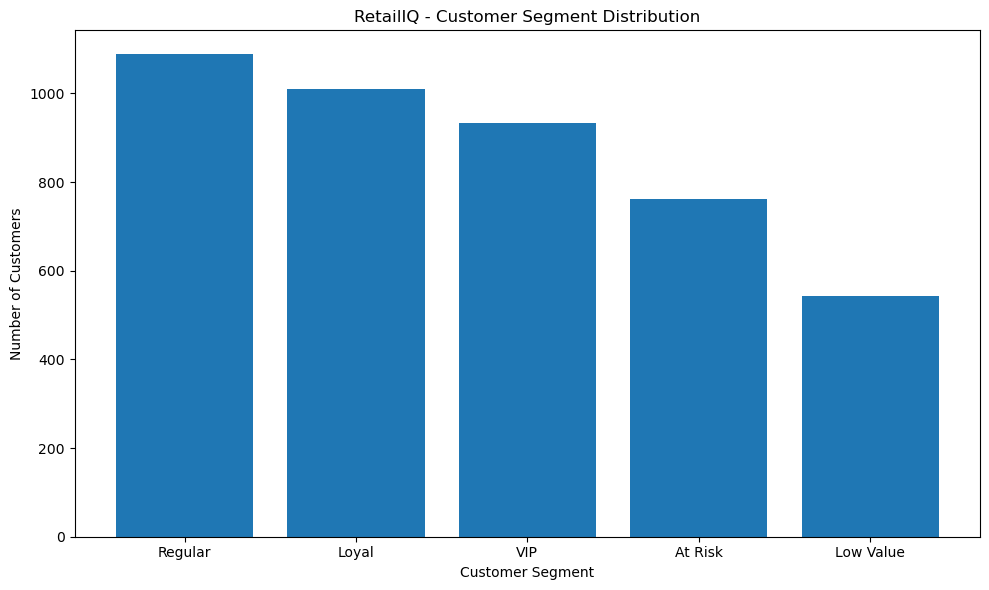

In [5]:
# ===== CUSTOMER SEGMENT DISTRIBUTION =====

plt.figure(figsize=(10, 6))

plt.bar(
    segment_counts["Segment"],
    segment_counts["Customers"]
)

plt.title("RetailIQ - Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [6]:
# ===== SEGMENT BEHAVIOR =====

segment_behavior = (
    rfm
    .groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        AverageRecency=("Recency", "mean"),
        AverageFrequency=("Frequency", "mean"),
        AverageMonetary=("Monetary", "mean")
    )
    .sort_values("AverageMonetary", ascending=False)
    .reset_index()
)

display(segment_behavior)

,Segment,Customers,AverageRecency,AverageFrequency,AverageMonetary
0,VIP,933,14.639871,11.752412,6689.759668
1,Loyal,1010,43.406931,3.857426,1389.110526
2,Regular,1088,85.531250,2.009191,807.018118
3,At Risk,763,147.342071,1.226737,341.410526
4,Low Value,544,254.490809,1.009191,191.414614


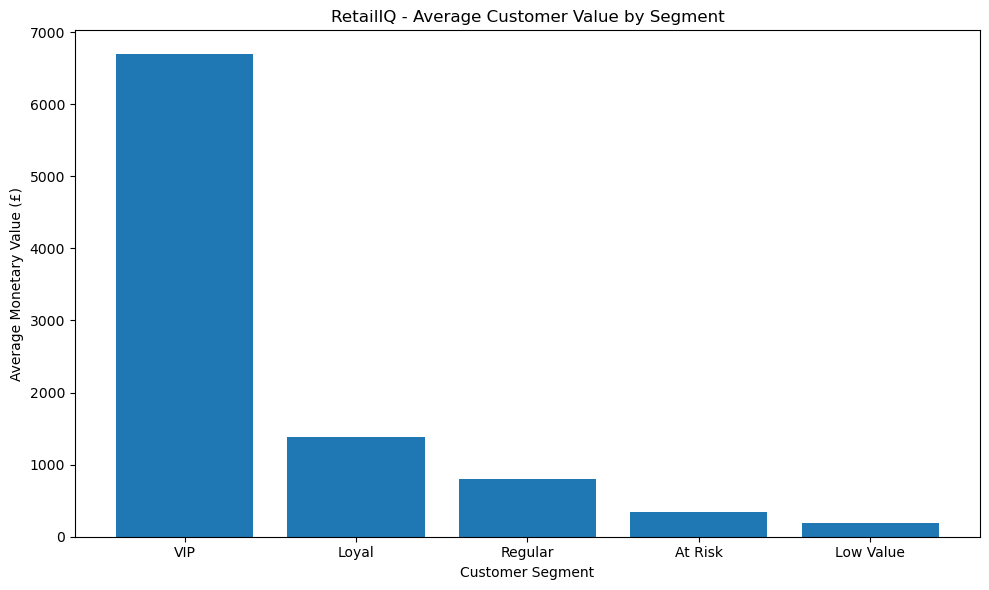

In [7]:
# ===== AVERAGE CUSTOMER VALUE BY SEGMENT =====

plt.figure(figsize=(10, 6))

plt.bar(
    segment_behavior["Segment"],
    segment_behavior["AverageMonetary"]
)

plt.title("RetailIQ - Average Customer Value by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Monetary Value (£)")

plt.tight_layout()
plt.show()

In [8]:
# ===== SAVE SEGMENTATION RESULTS =====

segment_behavior.to_csv(
    "../data/processed/segmentation_analysis.csv",
    index=False
)

print("Segmentation analysis saved successfully!")

Segmentation analysis saved successfully!
